In [3]:
import pandas as pd
import re
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.manifold import TSNE
from adjustText import adjust_text
import yaml

In [4]:
def load_deduplicated_courses(filename):
    df = pd.read_csv(filename, index_col=0)
 
    id_to_cols = defaultdict(list)
    for col in df.columns:
        parts = col.split(' | ')
        course_id = parts[0].strip()
        id_to_cols[course_id].append(col)
 
    merged_cols = {}
    for course_id, cols in id_to_cols.items():
        teachers = []
        names = []
        for col in cols:
            parts = [p.strip() for p in col.split(' | ')]
            if len(parts) >= 2:
                names.append(parts[1])
            if len(parts) >= 3 and parts[2]:
                teachers.append(parts[2])
 
        base_name = min(names, key=len) if names else course_id
        unique_teachers = list(dict.fromkeys(teachers))
        teacher_str = '; '.join(unique_teachers) if unique_teachers else ''
        new_col = f"{course_id} | {base_name} | {teacher_str}"
 
        numeric_data = df[cols].apply(pd.to_numeric, errors='coerce')
        merged_cols[new_col] = numeric_data.max(axis=1)
 
    result = pd.DataFrame(merged_cols)
    result.index = df.index
    return result

In [5]:
def load_course_degrees(filename):
    df = pd.read_csv(filename)
    df = df.dropna(subset=['course_title', 'degree_course'])
    result = defaultdict(list)
    for _, row in df.iterrows():
        course_id = str(row['course_title']).split('-')[0].strip()
        degree = row['degree_course']
        if degree not in result[course_id]:
            result[course_id].append(degree)
    return dict(result)

In [6]:
def filter_programmes_to_df(programmes, df):
    df_ids = {col.split(' | ')[0].strip() for col in df.columns}
    return {course_id: degrees for course_id, degrees in programmes.items() if course_id in df_ids}
 

In [7]:
def plot_tsne(df, programmes, output_file='tsne_courses.png'):
     
    X = df.T.values
    coords = TSNE(n_components=2, random_state=42, perplexity=10).fit_transform(X)
 
    titles, degrees = [], []
    for col in df.columns:
        parts = [p.strip() for p in col.split(' | ')]
        titles.append(parts[1] if len(parts) > 1 else parts[0])
        cid = parts[0]
        d = programmes.get(cid, ['Unknown'])
        degrees.append(d[0] if d else 'Unknown')
 
    unique_degrees = sorted(set(degrees))
    colour_map = {deg: cm.tab20(i / len(unique_degrees)) for i, deg in enumerate(unique_degrees)}
    colours = [colour_map[d] for d in degrees]
 
    fig, ax = plt.subplots(figsize=(20, 16))
    ax.scatter(coords[:, 0], coords[:, 1], c=colours, alpha=0.7, s=30)
    texts = [ax.text(coords[i, 0], coords[i, 1], title, fontsize=4) for i, title in enumerate(titles)]
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='grey', lw=0.3))

    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colour_map[d],
               markersize=6, label=d) for d in unique_degrees]
    ax.legend(handles=handles, fontsize=6, loc='upper left', bbox_to_anchor=(1, 1),
              title='Degree programme')
    ax.set_title('Course t-SNE coloured by degree programme')
    ax.axis('off')
 
    plt.tight_layout()
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    plt.close()

In [34]:
def plot_tsne_2(disi_df, others_df, output_file='tsne_disi_others.png'):

    disi_cols = set(disi_df.columns)
    merged_df = pd.concat([disi_df, others_df], axis=1)
    merged_df = merged_df.loc[:, ~merged_df.columns.duplicated()]

    X      = merged_df.T.values
    coords = TSNE(n_components=2, random_state=42, perplexity=10).fit_transform(X)

    colours = ['steelblue' if col in disi_cols else 'tomato' for col in merged_df.columns]
    titles  = [col.split(' | ')[1].strip() if ' | ' in col else col for col in merged_df.columns]

    fig, ax = plt.subplots(figsize=(20, 16))
    ax.scatter(coords[:, 0], coords[:, 1], c=colours, alpha=0.7, s=30)

    texts = [ax.text(coords[i, 0], coords[i, 1], title, fontsize=4) for i, title in enumerate(titles)]
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='grey', lw=0.3))

    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=8, label='DISI'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato',    markersize=8, label='Non-DISI'),
    ]
    ax.legend(handles=handles, fontsize=9, title='Group')
    ax.set_title('Course t-SNE: DISI vs non-DISI')
    ax.axis('off')

    plt.tight_layout()
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    plt.close()

In [44]:
def plot_tsne_3(disi_df, others_df, programmes, output_file='tsne_disi_others.png', perplexity=30):

    disi_cols = set(disi_df.columns)
    merged_df = pd.concat([disi_df, others_df], axis=1)
    merged_df = merged_df.loc[:, ~merged_df.columns.duplicated()]

    X      = merged_df.T.values
    coords = TSNE(n_components=2, random_state=42, perplexity=perplexity).fit_transform(X)

    filtered = filter_programmes_to_df(programmes, merged_df)

    colour_map = {'DISI': '#2196F3', 'Non-DISI': '#FF5722'}
    marker_map = {'magistrale': '*', 'triennale': 'o', 'unknown': 'D'}
    size_map   = {'magistrale': 120, 'triennale': 50, 'unknown': 50}

    groups, markers, colours, titles = [], [], [], []
    for col in merged_df.columns:
        cid   = col.split(' | ')[0].strip()
        title = col.split(' | ')[1].strip() if ' | ' in col else col
        titles.append(title)

        group = 'DISI' if col in disi_cols else 'Non-DISI'
        groups.append(group)
        colours.append(colour_map[group])

        degrees = filtered.get(cid, [])
        degree_str = ' '.join(degrees).lower()
        if 'magistrale' in degree_str:
            markers.append('magistrale')
        elif 'triennale' in degree_str or 'laurea in' in degree_str:
            markers.append('triennale')
        else:
            markers.append('unknown')

    fig, ax = plt.subplots(figsize=(20, 16))

    for marker_key in marker_map:
        for group in colour_map:
            idx = [i for i, (m, g) in enumerate(zip(markers, groups)) if m == marker_key and g == group]
            if idx:
                ax.scatter(
                    coords[idx, 0], coords[idx, 1],
                    c=colour_map[group],
                    marker=marker_map[marker_key],
                    s=size_map[marker_key],
                    alpha=0.7,
                    label=f'{group} – {marker_key}',
                )

    texts = [ax.text(coords[i, 0], coords[i, 1], title, fontsize=4) for i, title in enumerate(titles)]
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='grey', lw=0.3))

    ax.legend(fontsize=8, title='Group – Level', loc='upper left', bbox_to_anchor=(1, 1))
    ax.set_title('Course t-SNE: DISI vs non-DISI, Magistrale vs Triennale')
    ax.axis('off')

    plt.tight_layout()
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    plt.close()

In [8]:
def filter_df_by_yaml_list(df, yaml_filename):

    with open(yaml_filename) as f:
        courses = yaml.safe_load(f)

    ids = {str(c['id']).strip() for c in courses}
    matching_cols = [col for col in df.columns if col.split(' | ')[0].strip() in ids]
    return df[matching_cols]

In [23]:
def filter_df_by_yaml_list1(df, courses_filename):
    
    with open(courses_filename) as f:
        data = yaml.safe_load(f)
    
    disi_ids = {str(c['id']).strip() for entry in data for c in (entry.get('Courses') or [])}
    
    matching_cols = [col for col in df.columns if col.split(' | ')[0].strip() in disi_ids]
    return df[matching_cols]

In [9]:
filename='course_cluster_matrix193features_fullcourseNames.csv'
original_df = pd.read_csv(filename, index_col=0)

df = load_deduplicated_courses(filename)

print(f"Original columns: {len(original_df.columns)}")
print(f"Deduplicated columns: {len(df.columns)}")
print(f"Rows (clusters): {len(original_df)},  {len(df)}")
print(f"\nSample original columns:")
for col in list(original_df.columns)[:10]:
    print(f"  {col}")
print(f"\nSample columns:")
for col in list(df.columns)[:5]:
    print(f"  {col}")

Original columns: 723
Deduplicated columns: 318
Rows (clusters): 193,  193

Sample original columns:
  91258 | NATURAL LANGUAGE PROCESSING | Barron Cedeno, Luis Alberto
  B0385 | NATURAL LANGUAGE PROCESSING (NLP) | Barron Cedeno, Luis Alberto
  88145 | FONDAMENTI DI INFORMATICA P-1 | Bartolini, Andrea
  69430 | ARCHITETTURA DEI CALCOLATORI ELETTRONICI M | Bartolini, Andrea
  B8561 | ARCHITETTURE DEI CALCOLATORI M | Bartolini, Andrea
  78810 | REAL TIME SYSTEMS FOR AUTOMATION M (Modulo 4) | Galassi, Andrea
  B5665 | REAL TIME SYSTEMS AND PROGRAMMING FOR AUTOMATION M (Modulo 4) | Galassi, Andrea
  95644 | RETI DI CALCOLATORI E PROGRAMMAZIONE DI RETE | Melis, Andrea
  96995 | PROGRAMMABLE NETWORKING (Modulo 2) | Melis, Andrea
  11929 | ALGORITMI E STRUTTURE DATI (CL.A) (Modulo 2) | Melis, Andrea

Sample columns:
  91258 | NATURAL LANGUAGE PROCESSING | Barron Cedeno, Luis Alberto; Mancini, Eleonora; Tamburini, Fabio; Ruggeri, Federico; Torroni, Paolo
  B0385 | NATURAL LANGUAGE PROCESSING (

In [10]:
id_to_title = {col.split(' | ')[0].strip(): col.split(' | ')[1].strip() for col in df.columns}

In [11]:
course_headers_file="../data/course_headers.csv"
programmes=load_course_degrees(course_headers_file)
programmes=filter_programmes_to_df(programmes, df)
print(len(programmes))
print(programmes)

318
{'99195': ['Laurea Magistrale in Automation Engineering Laurea Magistrale in Ingegneria elettronica'], '29227': ["Laurea in Ingegneria dell'automazione", 'Laurea in Ingegneria energetica', 'Laurea in Ingegneria meccanica'], '28011': ['Laurea in Ingegneria elettronica e telecomunicazioni', "Laurea in Ingegneria dell'automazione", 'Laurea in Ingegneria informatica'], 'B0009': ['Laurea Magistrale in Ingegneria e scienze informatiche Laurea Magistrale in Ingegneria e scienze informatiche'], '81612': ['Laurea Magistrale in Ingegneria e scienze informatiche'], '95648': ['Laurea in Tecnologie dei sistemi informatici'], '93034': ['Laurea in Ingegneria informatica', "Laurea in Ingegneria dell'energia elettrica"], '91762': ['Laurea Magistrale in Artificial Intelligence'], 'B0069': ["Laurea Magistrale in Governance e politiche dell'innovazione digitale"], '00819': ['Laurea in Informatica per il management', 'Laurea in Tecnologie dei sistemi informatici', 'Laurea in Ingegneria e scienze inform

[('00819', 'PROGRAMMAZIONE', 4), ('91250', 'DEEP LEARNING', 4), ('07276', 'INFORMATICA', 7)]


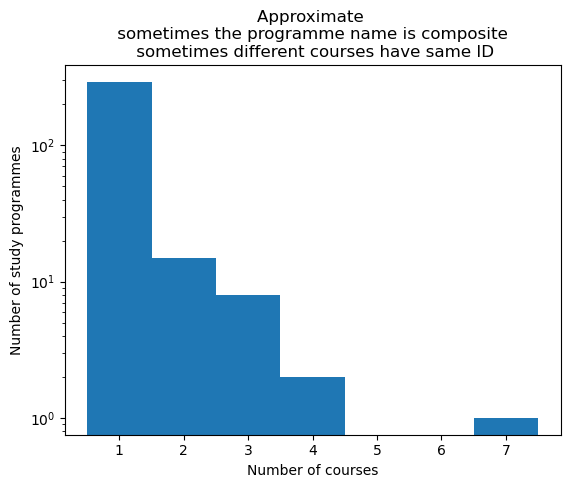

In [12]:
np=[len(p) for p in programmes.values()]
plt.hist(np, bins=[0.5+i for i in range(8)])
plt.yscale('log')
plt.ylabel("Number of study programmes")
plt.xlabel("Number of courses")
plt.title("Approximate \n sometimes the programme name is composite \n sometimes different courses have same ID")

c=[(k,id_to_title[k], len(programmes[k])) for k in programmes if len(programmes[k])>3]
print(c)

In [13]:
programmes["07276"]
#https://www.unibo.it/it/studiare/insegnamenti-competenze-trasversali-moocs/insegnamenti/insegnamento/2025/529078
#https://www.unibo.it/it/studiare/insegnamenti-competenze-trasversali-moocs/insegnamenti/insegnamento/2025/521128



['Laurea Magistrale a Ciclo Unico in Odontoiatria e protesi dentaria',
 'Laurea in Dietistica (abilitante alla professione sanitaria di dietista)',
 'Laurea in Matematica',
 'Laurea in Scienze e tecniche psicologiche',
 'Laurea in Fisioterapia (abilitante alla professione sanitaria di fisioterapista)',
 'Laurea in Igiene dentale (abilitante alla professione sanitaria di igienista dentale)',
 'Laurea in Scienze statistiche']

In [14]:
programmes["00819"]

['Laurea in Informatica per il management',
 'Laurea in Tecnologie dei sistemi informatici',
 'Laurea in Ingegneria e scienze informatiche',
 'Laurea in Informatica']

In [15]:
plot_tsne(df, programmes, output_file='tsne_courses_unique.png')
plot_tsne(original_df, programmes, output_file='tsne_courses_all.png')

221 [-0.76366875 -0.37612193]
223 [-0.26151272 -0.8504473 ]
106 [-0.23776522  0.55200231]
107 [ 0.14902693 -0.75948548]
321 [0.33304803 0.43788378]
610 [-0.87325091  0.61037289]
322 [0.82824034 0.41383435]
611 [-0.93514891 -0.76564401]
185 [ 0.52530036 -0.31624861]
382 [0.36061063 0.61755193]
350 [ 0.65001823 -0.18985031]
591 [-0.37693819  0.71304039]
351 [ 0.8888376  -0.04882884]
592 [ 0.88304908 -0.06717027]
54 [-0.83880658  0.65963176]
117 [ 0.48392361 -0.05444877]
53 [-0.27052709  0.01545668]
116 [ 0.25368696 -0.50010867]
180 [0.08422119 0.88397255]
300 [-0.70766351 -0.15937906]
135 [-0.56705579 -0.63185502]
192 [0.7975248  0.84479173]
246 [0.5557892  0.03023629]
527 [-0.79574789 -0.26021241]
710 [-0.90588085  0.43077525]
422 [ 0.20178825 -0.91252422]
435 [0.00240211 0.68350563]
600 [ 0.94653654 -0.61632042]
119 [-0.99397126 -0.86065114]
243 [-0.0885562  -0.55753614]
401 [ 0.04505587 -0.57744304]
402 [ 0.35010286 -0.73577731]
473 [-0.06086171 -0.47183862]
475 [-0.49241013  0.510407

In [16]:
disi_df=filter_df_by_yaml_list(original_df,"../queries/courses_disi.yaml")
plot_tsne(disi_df, programmes, output_file='tsne_courses_all_disi.png')

161 [0.76718094 0.01736888]
294 [-0.65162923  0.64329277]
387 [-0.05672154  0.40777102]
160 [0.8322249  0.41493572]
293 [0.53981312 0.90286595]
386 [ 0.13274029 -0.95291712]
46 [ 0.49651631 -0.17438862]
210 [-0.98424548 -0.80439758]
302 [-0.07464468  0.35560609]
400 [ 0.94497121 -0.04760789]
45 [0.547722   0.88253009]
209 [-0.70201465 -0.38746401]
301 [-0.4850184  -0.76878455]
399 [-0.62289697  0.27415975]
105 [-0.87419349  0.0010204 ]
179 [-0.33024989 -0.79418851]
231 [ 0.04900366 -0.16264965]
106 [0.50154029 0.36385539]
180 [0.58375302 0.43711134]
232 [0.01840969 0.3867753 ]
104 [0.89575923 0.56155191]
177 [-0.56493939  0.31597125]
229 [ 0.47001509 -0.33638785]
50 [-0.41824527  0.38297239]
413 [-0.27811518 -0.03802486]
85 [-0.61231992 -0.47277373]
168 [ 0.51335992 -0.90816152]
280 [ 0.43477367 -0.79168977]
354 [-0.80360977  0.20976133]
375 [-0.87473281 -0.93797483]
288 [-0.93775878  0.73332383]
289 [ 0.82975433 -0.24002565]
343 [-0.46609549  0.723448  ]
424 [-0.9926116   0.74810259]


In [17]:
disi_unique_df=filter_df_by_yaml_list(df,"../queries/courses_disi.yaml")
plot_tsne(disi_unique_df, programmes, output_file='tsne_courses_unique_disi.png')

170 [0.55949536 0.73964249]
171 [ 0.21706153 -0.85960533]
151 [0.0300014  0.60699465]
152 [ 0.53757146 -0.68806305]
70 [-0.43601004  0.88196595]
71 [ 0.30532132 -0.16082577]


In [26]:
others_df=filter_df_by_yaml_list1(original_df,"../queries/courses_non_disi.yaml")
plot_tsne(others_df, programmes, output_file='tsne_courses_all_non_disi.png')

130 [-0.66372549 -0.7797022 ]
158 [-0.29628493  0.63170815]
210 [-0.56826787 -0.76895535]
269 [-0.93981113  0.826197  ]
65 [ 0.43392695 -0.83152329]
124 [ 0.45558972 -0.69571305]
153 [-0.93865243 -0.3689265 ]
66 [ 0.66778335 -0.15015658]
125 [ 0.73180624 -0.59878887]
154 [-0.95580569 -0.57009034]
64 [-0.97327831 -0.64249103]
122 [-0.61495378 -0.36730422]
151 [0.5737242  0.83515086]
28 [-0.36185798 -0.11121694]
233 [ 0.08082519 -0.65262667]
6 [ 0.04376705 -0.23922912]
235 [-0.8512788   0.79888468]
88 [ 0.52233852 -0.39794699]
256 [-0.57435016 -0.84887321]
21 [-0.09169013 -0.13566574]
76 [0.23198224 0.21147563]
4 [-0.12071129  0.46100159]
272 [0.13635679 0.66138179]
100 [ 0.48951005 -0.0600538 ]
304 [ 0.72871874 -0.68281885]
27 [0.63512917 0.41016874]
96 [-0.91851868 -0.08162052]
3 [0.64468957 0.08463503]
271 [-0.61494059 -0.39630883]
101 [-0.43671515  0.42066206]
190 [-0.04605942 -0.87351353]
118 [-0.50032877 -0.67845386]
261 [ 0.90843375 -0.72738455]
85 [0.78418744 0.8942932 ]
86 [-0.4

In [27]:
others_unique_df=filter_df_by_yaml_list1(df,"../queries/courses_non_disi.yaml")
plot_tsne(others_unique_df, programmes, output_file='tsne_courses_unique_non_disi.png')

In [41]:
plot_tsne_3(disi_unique_df,others_unique_df,programmes, "disi_others_unique1.png",10)

70 [ 0.27569222 -0.75148009]
71 [ 0.77349232 -0.80064864]
142 [0.6551136  0.93376188]
144 [ 0.76354683 -0.75527611]


In [45]:
plot_tsne_3(disi_df,others_df,programmes, "disi_others_all1.png",30)

93 [ 0.35648765 -0.57068804]
94 [ 0.34865364 -0.10040962]
133 [-0.01332122  0.20565089]
134 [-0.47519389 -0.2371839 ]
340 [-0.78310392 -0.80661208]
342 [-0.84470684 -0.23267665]
642 [0.76981333 0.97218923]
643 [-0.7818334  -0.70885393]
221 [-0.98273927 -0.34585741]
453 [-0.81553675  0.84308018]
227 [-0.91644665 -0.6260452 ]
443 [-0.65616058 -0.71864924]
18 [ 0.12129888 -0.40083996]
49 [0.79419857 0.76981261]
254 [ 0.61780072 -0.02381915]
427 [-0.94082147 -0.01126745]
17 [-0.12954017  0.82478349]
48 [-0.80638099  0.44092549]
261 [0.89941535 0.68629273]
307 [-0.81219918  0.54646713]
27 [-0.92941072 -0.17920534]
211 [0.20763763 0.45520728]
85 [-0.97050645  0.89626899]
168 [ 0.85166574 -0.29431797]
247 [0.48253586 0.23286778]
283 [0.00170827 0.3756089 ]
322 [ 0.7807051  -0.47920545]
263 [ 0.68258365 -0.34820298]
316 [-0.73577022 -0.29815275]
149 [-0.52881474 -0.89199196]
350 [0.9001697  0.42521113]
5 [0.82109735 0.94128519]
295 [-0.76420069 -0.42443226]
81 [0.39633838 0.51678479]
146 [-0.1